# Практична робота 3.5
# Аналіз коментарів Reddit про війну в Україні

**Набір даних:** коментарі з двох мегатредів сабреддіту r/europe про російсько-українську війну
**Файл:** `comments_data.csv` (18 183 записи, 3 колонки)
**Тематика:** військово-аналітична

## Про що робота

У даних немає жодної числової колонки: є тільки `comment_id`, текст коментаря та `post_id`.
Тому кількісні ознаки я конструюю з самого тексту — довжину, кількість посилань, частку
великих літер, тональність тощо. На цих ознаках далі будую описову статистику, кореляційний
аналіз і дві моделі.

**Питання дослідження:**
1. Чи можна за структурою коментаря передбачити його довжину?
2. Чи можна визначити, до якої з двох дискусій належить коментар?

## Зміст
1. Завантаження та попередній перегляд
2. Очищення даних
3. Конструювання ознак
4. Трансформація: нормалізація та кодування
5. Декомпозиція: поділ вибірки та кореляційний аналіз
6. Описова статистика та візуалізація
7. Побудова моделей
8. Висновки

In [1]:
# Бібліотека для аналізу тональності англомовного тексту
try:
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
except ImportError:
    !pip install vaderSentiment -q
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

import os, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (r2_score, mean_absolute_error, root_mean_squared_error,
                             accuracy_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 170)

os.makedirs("figures", exist_ok=True)
os.makedirs("output", exist_ok=True)

def save(name):
    plt.savefig(f"figures/{name}.png", dpi=120, bbox_inches="tight")
    plt.show()

RANDOM_STATE = 42
print("pandas", pd.__version__)

pandas 3.0.2


## 1. Завантаження та попередній перегляд

In [2]:
CANDIDATES = ["comments_data.csv", "data/comments_data.csv",
              "/mnt/user-data/uploads/comments_data.csv"]
CSV_PATH = next((p for p in CANDIDATES if os.path.exists(p)), None)
if CSV_PATH is None:
    raise FileNotFoundError("Покладіть comments_data.csv поруч із ноутбуком або в папку data/")

df = pd.read_csv(CSV_PATH)
print("Файл:", CSV_PATH)
print("Рядків:", df.shape[0], "| Колонок:", df.shape[1])
df.head()

Файл: /mnt/user-data/uploads/comments_data.csv
Рядків: 18183 | Колонок: 3


,comment_id,comment_body,post_id
0,j4spbvz,"Back in December, we asked for some feedback o...",10eps9y
1,j5t53d7,It is funny to read the pro-Russian far-right ...,10eps9y
2,j509t84,> [Denmark donates artillery to Ukraine](https...,10eps9y
3,j60rk9u,[Auschwitz museum: Russia not invited to event...,10eps9y
4,j4sbv6e,...hoping the L will be the one Russia takes,10eps9y


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18183 entries, 0 to 18182
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   comment_id    18183 non-null  str  
 1   comment_body  18183 non-null  str  
 2   post_id       18183 non-null  str  
dtypes: str(3)
memory usage: 426.3 KB


In [4]:
pd.DataFrame({
    "тип": df.dtypes.astype(str),
    "унікальних": df.nunique(),
    "пропущено": df.isna().sum(),
})

,тип,унікальних,пропущено
comment_id,str,18183,0
comment_body,str,17437,0
post_id,str,2,0


Три колонки, усі текстові. `comment_id` унікальний для кожного рядка, тобто це ідентифікатор.
`post_id` має лише два значення — коментарі зібрані з двох обговорень.

In [5]:
print("Коментарів за обговоренням:")
print(df["post_id"].value_counts().to_string())

print("\nПриклади коментарів:\n")
for txt in df["comment_body"].astype(str).head(3):
    print("-" * 90)
    print(txt[:300])

Коментарів за обговоренням:
post_id
10eps9y    9603
yhqh49     8580

Приклади коментарів:

------------------------------------------------------------------------------------------
Back in December, we asked for some feedback on a possible drive for donations to Ukrainians in Ukraine.

That thread is up! https://www.reddit.com/r/europe/comments/10eoguo/ukraine_donation_thread/

/u/svhmj
------------------------------------------------------------------------------------------
It is funny to read the pro-Russian far-right and far-left corners of European politics. According to them Russia is easily winning the war without breaking a sweat. However 14 German tanks are an existential threat to Russia and they would be right to nuke all of Europe.
------------------------------------------------------------------------------------------
> [Denmark donates artillery to Ukraine](https://www.fmn.dk/da/nyheder/2023/danmark-donerer-artilleri-til-ukraine/)
> 
> With broad support from the Danis

In [6]:
# Які слова відрізняють одне обговорення від іншого.
# Просто найчастотніші слова тут не годяться: у обох тредах лідирують ukraine та russia.
# Тому рахую відношення відносних частот у двох тредах.
from collections import Counter

STOP = set(("the a an and or but if of to in on for with is are was were be been it this that "
            "they them he she you i we as at by from not no so do does did have has had will "
            "would can could there their his her its about more most other than then out up "
            "down what which who when where why how all any some such only own same too very "
            "don now me my your our i'm it's don't just like also even much well still being "
            "https www com twitter status reddit html amp").split())

counts, totals = {}, {}
for pid, g in df.groupby("post_id"):
    words = [w for w in re.findall(r"[a-z']{4,}", " ".join(g["comment_body"].astype(str)).lower())
             if w not in STOP]
    counts[pid] = Counter(words)
    totals[pid] = sum(counts[pid].values())

p1, p2 = list(counts)
rows = []
for w in set(counts[p1]) | set(counts[p2]):
    a, b = counts[p1][w], counts[p2][w]
    if a + b < 80:               # рідкісні слова дають нестабільні відношення
        continue
    rows.append({"слово": w, p1: a, p2: b,
                 "перевага": np.log2(((a / totals[p1]) + 1e-9) / ((b / totals[p2]) + 1e-9))})

diff = pd.DataFrame(rows)
print(f"Характерні для {p1}:")
print(diff.nlargest(12, "перевага").round(2).to_string(index=False))
print(f"\nХарактерні для {p2}:")
print(diff.nsmallest(12, "перевага").round(2).to_string(index=False))

Характерні для 10eps9y:
      слово  10eps9y  yhqh49  перевага
   baerbock       85       0     18.53
   leopards      406       2      7.13
       leos       99       1      6.09
    leopard      693       8      5.90
     abrams      510      16      4.45
 challenger       91       3      4.38
      tanks     2054     101      3.81
maintenance      100       5      3.78
     scholz      426      22      3.74
  coalition      162      10      3.48
 chancellor       93       6      3.41
       olaf       77       5      3.41

Характерні для yhqh49:
        слово  10eps9y  yhqh49  перевага
      kherson       29     522     -4.71
investigation        7      80     -4.05
        river       12     103     -3.64
   withdrawal       11      89     -3.56
         bank       17     118     -3.33
        water       13      90     -3.33
      retreat       17     114     -3.28
       winter       24     131     -2.99
       bridge       18      93     -2.91
      missile       90     390     

Обидва треди говорять про Україну та Росію, тому спільні слова нічого не пояснюють.
Різниця видно у специфічній лексиці:

| post_id | Тема | Період |
|---------|------|--------|
| `10eps9y` | Постачання танків Leopard 2, позиція Німеччини | січень 2023 |
| `yhqh49` | Звільнення Херсона, зернова угода, іранські дрони | листопад 2022 |

Далі підписую їх зрозумілими назвами замість технічних ідентифікаторів.

## 2. Очищення даних

Reddit замінює видалені коментарі рядками `[deleted]` та `[removed]`. Текст у них відсутній,
тому для аналізу вони марні: будь-яка ознака з них буде артефактом, а не властивістю коментаря.
Видаляю їх разом із дублікатами та порожніми рядками.

In [7]:
print("Пропущені значення до очищення:")
print(df.isna().sum().to_string())

df_clean = df.copy()
df_clean["comment_body"] = df_clean["comment_body"].astype(str)
start_n = len(df_clean)

# 2.1 видалені модерацією коментарі
mask_del = df_clean["comment_body"].str.strip().isin(["[deleted]", "[removed]"])
print(f"\n[deleted] / [removed]: {mask_del.sum()} ({mask_del.mean()*100:.2f}%)")
df_clean = df_clean[~mask_del]

# 2.2 дублікати
dup_rows = df_clean.duplicated().sum()
dup_ids = df_clean["comment_id"].duplicated().sum()
df_clean = df_clean.drop_duplicates(subset="comment_id")
print(f"Дублікатів рядків: {dup_rows}, дублікатів comment_id: {dup_ids}")

# 2.3 порожні тексти
empty = (df_clean["comment_body"].str.strip().str.len() == 0).sum()
df_clean = df_clean[df_clean["comment_body"].str.strip().str.len() > 0]
print(f"Порожніх коментарів: {empty}")

df_clean = df_clean.reset_index(drop=True)
print(f"\nБуло {start_n} -> стало {len(df_clean)} (втрачено {start_n - len(df_clean)} рядків, "
      f"{(start_n - len(df_clean))/start_n*100:.2f}%)")

Пропущені значення до очищення:
comment_id      0
comment_body    0
post_id         0

[deleted] / [removed]: 648 (3.56%)
Дублікатів рядків: 0, дублікатів comment_id: 0
Порожніх коментарів: 0

Було 18183 -> стало 17535 (втрачено 648 рядків, 3.56%)


Пропущених значень у файлі немає, тож заповнювати медіаною чи модою нічого не потрібно.
Такий блок я все одно наводжу нижче, у розділі 3, для сконструйованих ознак.

## 3. Конструювання ознак

Без цього кроку робота неможлива: у вихідній таблиці немає жодної кількісної змінної.
Витягую з тексту три групи ознак.

**Обсяг і структура.** Кількість символів, слів, речень, абзаців, середня довжина слова,
частка унікальних слів.

**Форматування й посилання.** Кількість URL, рядків-цитат (`>`), згадок користувачів (`/u/`),
цифр, знаків оклику та питання, частка великих літер.

**Тональність.** VADER рахує compound-оцінку від −1 до +1, а також частки позитивної та
негативної лексики. Модель побудована на словнику, налаштованому під короткі тексти соцмереж.

In [8]:
URL_RE = re.compile(r"https?://\S+")
t = df_clean["comment_body"]

feat = pd.DataFrame(index=df_clean.index)

# --- обсяг і структура ---
feat["char_count"]     = t.str.len()
feat["word_count"]     = t.str.split().str.len()
feat["sentence_count"] = t.str.count(r"[.!?]+").clip(lower=1)
feat["avg_word_len"]   = (t.str.replace(r"\s", "", regex=True).str.len() / feat["word_count"]).round(2)
feat["unique_ratio"]   = t.str.lower().apply(
                             lambda s: len(set(s.split())) / max(len(s.split()), 1)).round(3)
feat["n_paragraphs"]   = t.str.count(r"\n\n") + 1

# --- форматування й посилання ---
feat["link_count"] = t.str.count(URL_RE)
feat["quote_lines"] = t.str.count(r"(?m)^\s*>")
feat["exclam"]   = t.str.count(r"!")
feat["question"] = t.str.count(r"\?")
feat["digits"]   = t.str.count(r"\d")
feat["mentions"] = t.str.count(r"/?[ur]/\w+")
feat["caps_ratio"] = (t.str.count(r"[A-Z]") / t.str.count(r"[A-Za-z]").clip(lower=1)).round(3)

# --- тональність ---
analyzer = SentimentIntensityAnalyzer()
scores = t.apply(analyzer.polarity_scores)
feat["sent_compound"] = scores.apply(lambda d: d["compound"])
feat["sent_pos"] = scores.apply(lambda d: d["pos"])
feat["sent_neg"] = scores.apply(lambda d: d["neg"])

data = pd.concat([df_clean, feat], axis=1)
print("Створено ознак:", feat.shape[1])
feat.head()

Створено ознак: 16


,char_count,word_count,sentence_count,avg_word_len,unique_ratio,n_paragraphs,link_count,quote_lines,exclam,question,digits,mentions,caps_ratio,sent_compound,sent_pos,sent_neg
0,208,24,4,7.62,0.917,3,1,0,1,0,2,2,0.031,0.0000,0.000,0.000
1,272,47,3,4.81,0.830,1,0,0,0,0,2,0,0.041,0.1027,0.150,0.126
2,785,115,13,5.80,0.670,3,1,9,0,0,6,1,0.045,0.6908,0.050,0.011
3,385,42,3,8.14,0.952,3,1,1,0,0,0,0,0.023,0.0000,0.000,0.000
4,44,9,1,4.00,0.889,1,0,0,0,0,0,0,0.061,0.7603,0.483,0.000


In [9]:
# Похідні категоріальні змінні
data["topic"] = data["post_id"].map({"10eps9y": "Leopard (січ-2023)",
                                     "yhqh49":  "Херсон (лис-2022)"})
data["has_link"] = (data["link_count"] > 0).astype(int)
data["is_quote"] = (data["quote_lines"] > 0).astype(int)
data["sent_label"] = pd.cut(data["sent_compound"], [-1.01, -0.05, 0.05, 1.01],
                            labels=["негативний", "нейтральний", "позитивний"])
data["len_group"] = pd.qcut(data["word_count"], 3,
                            labels=["короткий", "середній", "довгий"])

NUM_COLS = list(feat.columns)
CAT_COLS = ["topic", "sent_label", "len_group"]

# Перевірка пропусків у нових ознаках
na = data[NUM_COLS].isna().sum()
if na.sum():
    print("Пропуски у сконструйованих ознаках:\n", na[na > 0])
    for c in NUM_COLS:
        data[c] = data[c].fillna(data[c].median())   # медіана стійкіша до викидів, ніж середнє
else:
    print("Пропусків у сконструйованих ознаках немає.")

print("Підсумкова форма:", data.shape)
data[["topic", "word_count", "link_count", "sent_compound", "sent_label", "len_group"]].head()

Пропусків у сконструйованих ознаках немає.
Підсумкова форма: (17535, 24)


,topic,word_count,link_count,sent_compound,sent_label,len_group
0,Leopard (січ-2023),24,1,0.0000,нейтральний,середній
1,Leopard (січ-2023),47,0,0.1027,позитивний,довгий
2,Leopard (січ-2023),115,1,0.6908,позитивний,довгий
3,Leopard (січ-2023),42,1,0.0000,нейтральний,довгий
4,Leopard (січ-2023),9,0,0.7603,позитивний,короткий


## 4. Трансформація даних

### 4.1 Нормалізація

Ознаки мають різні масштаби: `char_count` сягає тисяч, `caps_ratio` лежить у межах від 0 до 1.
Моделі з регуляризацією та метрики відстані через це працюють некоректно, тому приводжу все
до спільного масштабу двома способами.

`MinMaxScaler` стискає значення у відрізок [0, 1] і зберігає форму розподілу.
`StandardScaler` центрує на нулі з одиничною дисперсією; його зручніше читати, коли треба
порівняти коефіцієнти регресії між собою.

In [10]:
mm_scaler = MinMaxScaler()
scaled_mm = pd.DataFrame(mm_scaler.fit_transform(data[NUM_COLS]),
                         columns=[c + "_mm" for c in NUM_COLS], index=data.index)

std_scaler = StandardScaler()
scaled_std = pd.DataFrame(std_scaler.fit_transform(data[NUM_COLS]),
                          columns=[c + "_z" for c in NUM_COLS], index=data.index)

print("MinMax — діапазони після нормалізації:")
print(scaled_mm.agg(["min", "max"]).T.round(2).head().to_string())
print("\nStandard — середнє та відхилення:")
print(scaled_std.agg(["mean", "std"]).T.round(2).head().to_string())

MinMax — діапазони після нормалізації:
                   min  max
char_count_mm      0.0  1.0
word_count_mm      0.0  1.0
sentence_count_mm  0.0  1.0
avg_word_len_mm    0.0  1.0
unique_ratio_mm    0.0  1.0

Standard — середнє та відхилення:
                  mean  std
char_count_z      -0.0  1.0
word_count_z      -0.0  1.0
sentence_count_z   0.0  1.0
avg_word_len_z    -0.0  1.0
unique_ratio_z    -0.0  1.0


### 4.2 Логарифмування

Довжина коментарів має сильну правосторонню асиметрію: більшість коротких, окремі сягають
кількох тисяч символів. Логарифм стискає хвіст і наближає розподіл до нормального.

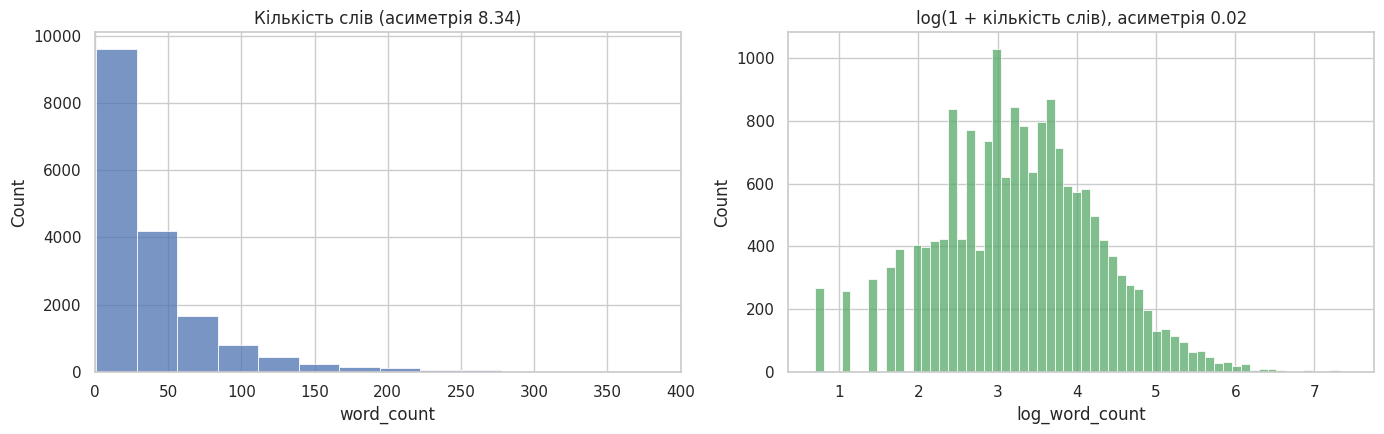

In [11]:
data["log_word_count"] = np.log1p(data["word_count"])
data["log_char_count"] = np.log1p(data["char_count"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
sns.histplot(data["word_count"], bins=60, ax=axes[0], color="#4c72b0")
axes[0].set_title(f"Кількість слів (асиметрія {data['word_count'].skew():.2f})")
axes[0].set_xlim(0, 400)
sns.histplot(data["log_word_count"], bins=60, ax=axes[1], color="#55a868")
axes[1].set_title(f"log(1 + кількість слів), асиметрія {data['log_word_count'].skew():.2f}")
plt.tight_layout()
save("log_transform")

### 4.3 Кодування категоріальних змінних

Label Encoding задає категоріям порядкові номери, чим створює хибне відчуття порядку.
Для `topic` це неприйнятно, тому застосовую One-Hot Encoding. Для `len_group` порядок існує
насправді (короткий < середній < довгий), тому там доречний Label Encoding.

In [12]:
# Label Encoding для впорядкованої категорії
data["len_group_code"] = data["len_group"].cat.codes
data["sent_label_code"] = data["sent_label"].cat.codes

# One-Hot Encoding для невпорядкованих
cols_before = set(data.columns)
data_encoded = pd.get_dummies(data, columns=["topic", "sent_label"],
                              prefix=["тема", "тон"], drop_first=False)

new_cols = [c for c in data_encoded.columns if c not in cols_before]
print("Створені dummy-колонки:", new_cols)
data_encoded[new_cols].head()

Створені dummy-колонки: ['тема_Leopard (січ-2023)', 'тема_Херсон (лис-2022)', 'тон_негативний', 'тон_нейтральний', 'тон_позитивний']


,тема_Leopard (січ-2023),тема_Херсон (лис-2022),тон_негативний,тон_нейтральний,тон_позитивний
0,True,False,False,True,False
1,True,False,False,False,True
2,True,False,False,False,True
3,True,False,False,True,False
4,True,False,False,False,True


## 5. Декомпозиція набору даних

### 5.1 Поділ на навчальну та тестову вибірки

In [13]:
train_set, test_set = train_test_split(data, test_size=0.2, random_state=RANDOM_STATE)
print(f"Навчальна: {len(train_set)} рядків ({len(train_set)/len(data)*100:.0f}%)")
print(f"Тестова:   {len(test_set)} рядків ({len(test_set)/len(data)*100:.0f}%)")

print("\nРозподіл тем зберігся в обох вибірках:")
print(pd.DataFrame({
    "навчальна, %": (train_set["topic"].value_counts(normalize=True) * 100).round(1),
    "тестова, %":   (test_set["topic"].value_counts(normalize=True) * 100).round(1),
}).to_string())

Навчальна: 14028 рядків (80%)
Тестова:   3507 рядків (20%)

Розподіл тем зберігся в обох вибірках:
                    навчальна, %  тестова, %
topic                                       
Leopard (січ-2023)          53.3        54.4
Херсон (лис-2022)           46.7        45.6


### 5.2 Кореляційний аналіз

Коефіцієнт Пірсона вимірює силу лінійного зв'язку. Орієнтир: |r| < 0.3 слабкий,
0.3–0.7 помірний, > 0.7 сильний.

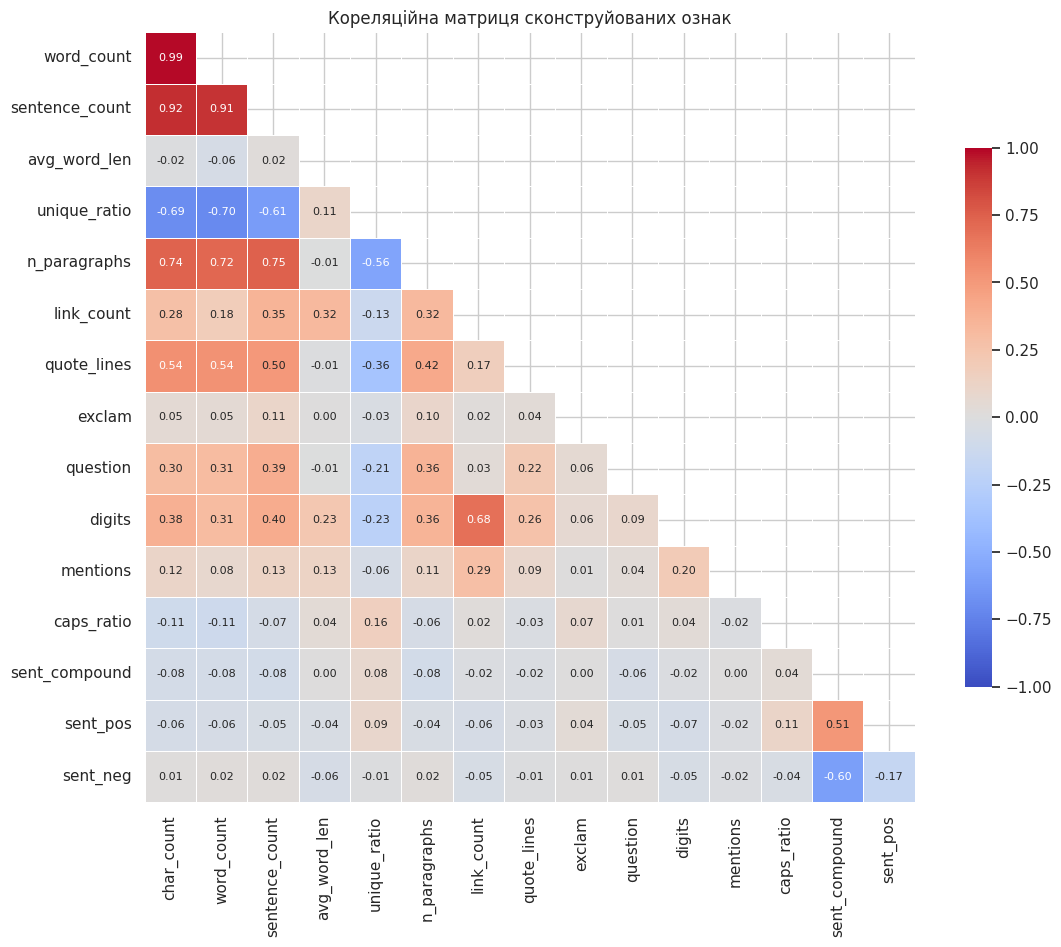

In [14]:
corr = data[NUM_COLS].corr(numeric_only=True)

tri = corr.iloc[1:, :-1]
mask = np.triu(np.ones_like(tri, dtype=bool), k=1)
plt.figure(figsize=(13, 10))
sns.heatmap(tri, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            vmin=-1, vmax=1, linewidths=.5, square=True, cbar_kws={"shrink": .7},
            annot_kws={"size": 8})
plt.title("Кореляційна матриця сконструйованих ознак")
save("correlation_matrix")

In [15]:
pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
             .stack().reset_index())
pairs.columns = ["ознака 1", "ознака 2", "r"]
pairs["|r|"] = pairs["r"].abs()
pairs["сила"] = pd.cut(pairs["|r|"], [0, .3, .7, 1.01],
                       labels=["слабкий", "помірний", "сильний"])
pairs.sort_values("|r|", ascending=False).head(15).round(3).reset_index(drop=True)

,ознака 1,ознака 2,r,|r|,сила
0,char_count,word_count,0.992,0.992,сильний
1,char_count,sentence_count,0.919,0.919,сильний
2,word_count,sentence_count,0.906,0.906,сильний
3,sentence_count,n_paragraphs,0.748,0.748,сильний
4,char_count,n_paragraphs,0.737,0.737,сильний
5,word_count,n_paragraphs,0.721,0.721,сильний
6,word_count,unique_ratio,-0.703,0.703,сильний
7,char_count,unique_ratio,-0.689,0.689,помірний
8,link_count,digits,0.680,0.680,помірний
9,sentence_count,unique_ratio,-0.614,0.614,помірний


## 6. Описова статистика та візуалізація

### 6.1 Описова статистика

In [16]:
data[NUM_COLS].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
char_count,17535.0,266.99,421.29,1.00,76.00,155.00,309.00,9763.0
word_count,17535.0,43.56,68.96,1.00,12.00,25.00,50.00,1660.0
sentence_count,17535.0,3.21,4.31,1.00,1.00,2.00,4.00,127.0
avg_word_len,17535.0,5.61,4.97,1.00,4.44,4.81,5.35,190.0
unique_ratio,17535.0,0.90,0.10,0.36,0.84,0.92,1.00,1.0
n_paragraphs,17535.0,1.88,1.78,1.00,1.00,1.00,2.00,39.0
link_count,17535.0,0.17,0.50,0.00,0.00,0.00,0.00,27.0
quote_lines,17535.0,0.32,1.37,0.00,0.00,0.00,0.00,51.0
exclam,17535.0,0.07,0.39,0.00,0.00,0.00,0.00,12.0
question,17535.0,0.33,0.80,0.00,0.00,0.00,0.00,18.0


In [17]:
stats = pd.DataFrame({
    "середнє": data[NUM_COLS].mean(),
    "медіана": data[NUM_COLS].median(),
    "ст. відхилення": data[NUM_COLS].std(),
    "IQR": data[NUM_COLS].quantile(.75) - data[NUM_COLS].quantile(.25),
    "асиметрія": data[NUM_COLS].skew(),
}).round(2)
stats["форма"] = np.where(stats["асиметрія"].abs() < 0.5, "симетричний",
                  np.where(stats["асиметрія"] > 0, "хвіст вправо", "хвіст вліво"))
stats.sort_values("асиметрія", ascending=False)

,середнє,медіана,ст. відхилення,IQR,асиметрія,форма
avg_word_len,5.61,4.81,4.97,0.91,14.62,хвіст вправо
link_count,0.17,0.00,0.50,0.00,13.31,хвіст вправо
quote_lines,0.32,0.00,1.37,0.00,13.29,хвіст вправо
exclam,0.07,0.00,0.39,0.00,11.52,хвіст вправо
mentions,0.03,0.00,0.19,0.00,10.63,хвіст вправо
caps_ratio,0.05,0.04,0.06,0.03,9.20,хвіст вправо
sentence_count,3.21,2.00,4.31,3.00,8.71,хвіст вправо
word_count,43.56,25.00,68.96,38.00,8.34,хвіст вправо
char_count,266.99,155.00,421.29,233.00,8.27,хвіст вправо
digits,3.37,0.00,9.00,2.00,6.81,хвіст вправо


In [18]:
print("Частоти категоріальних змінних:\n")
for c in CAT_COLS:
    vc = data[c].value_counts()
    pct = (vc / len(data) * 100).round(1)
    print(f"--- {c} ---")
    print(pd.DataFrame({"кількість": vc, "%": pct}).to_string(), "\n")

print(f"Коментарів з посиланням: {data['has_link'].mean()*100:.1f}%")
print(f"Коментарів із цитатою:   {data['is_quote'].mean()*100:.1f}%")

Частоти категоріальних змінних:

--- topic ---
                    кількість     %
topic                              
Leopard (січ-2023)       9381  53.5
Херсон (лис-2022)        8154  46.5 

--- sent_label ---
             кількість     %
sent_label                  
позитивний        6912  39.4
негативний        6885  39.3
нейтральний       3738  21.3 

--- len_group ---
           кількість     %
len_group                 
короткий        5969  34.0
довгий          5797  33.1
середній        5769  32.9 

Коментарів з посиланням: 14.2%
Коментарів із цитатою:   16.0%


### 6.2 Розподіли числових ознак

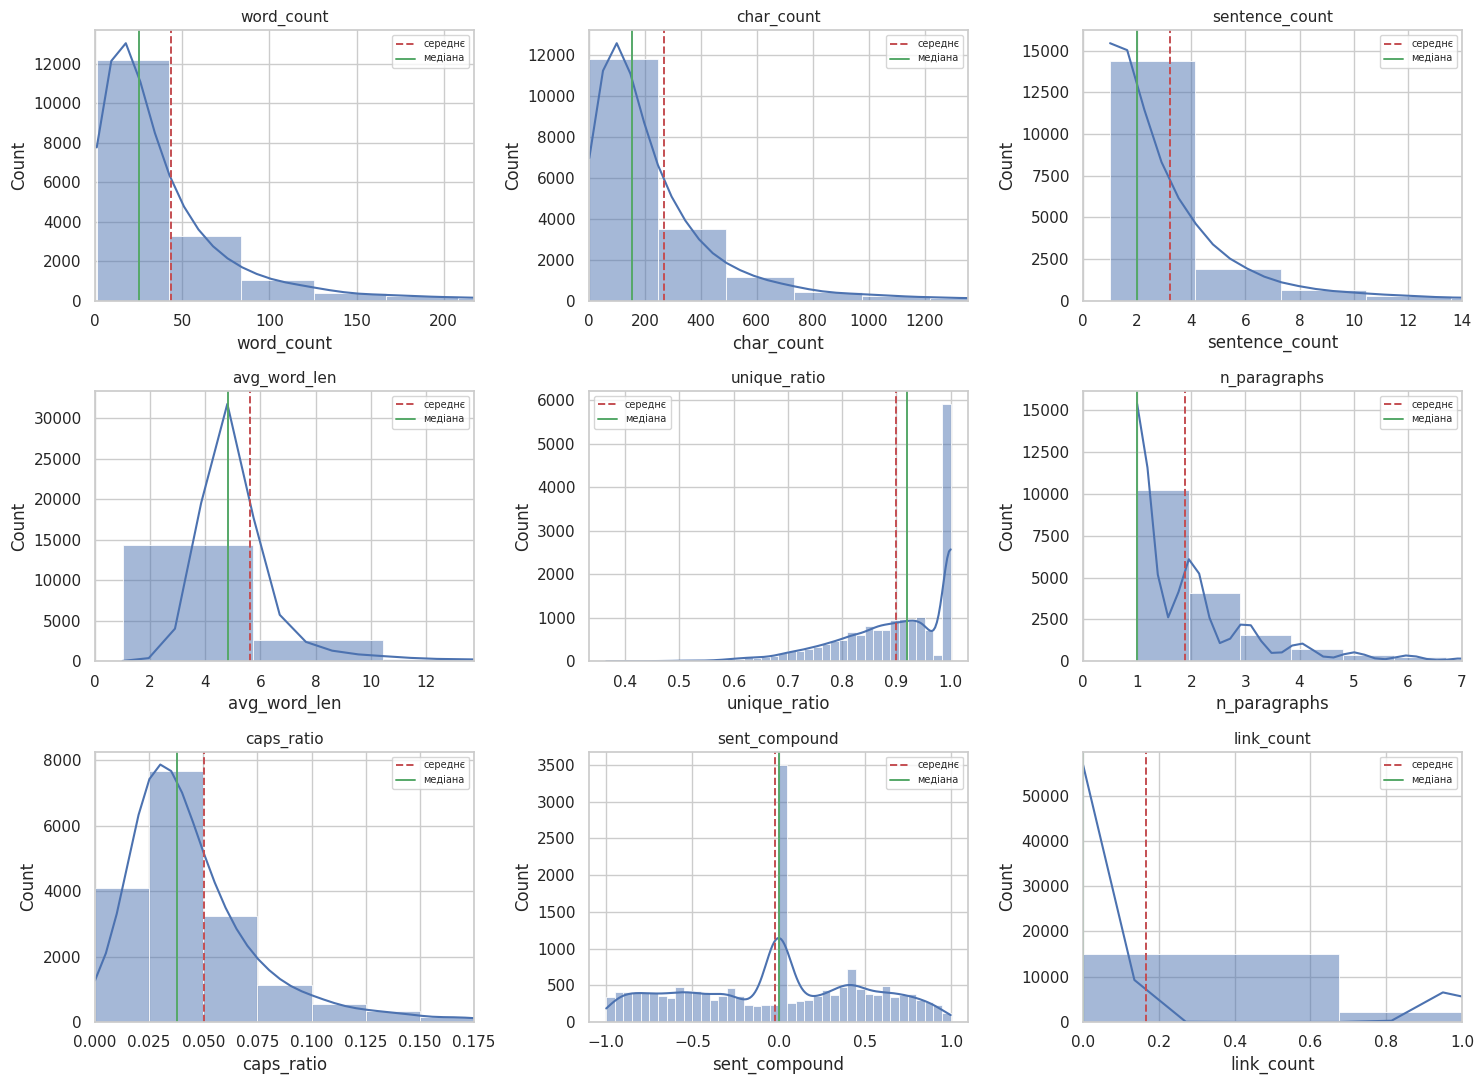

In [19]:
show = ["word_count", "char_count", "sentence_count", "avg_word_len",
        "unique_ratio", "n_paragraphs", "caps_ratio", "sent_compound", "link_count"]
fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, c in zip(axes.ravel(), show):
    sns.histplot(data[c], bins=40, kde=True, ax=ax, color="#4c72b0")
    ax.axvline(data[c].mean(), color="#c44e52", ls="--", lw=1.4, label="середнє")
    ax.axvline(data[c].median(), color="#55a868", lw=1.4, label="медіана")
    if data[c].skew() > 3:
        ax.set_xlim(0, data[c].quantile(.98))
    ax.set_title(c, fontsize=11)
    ax.legend(fontsize=7)
plt.tight_layout()
save("histograms")

### 6.3 Викиди

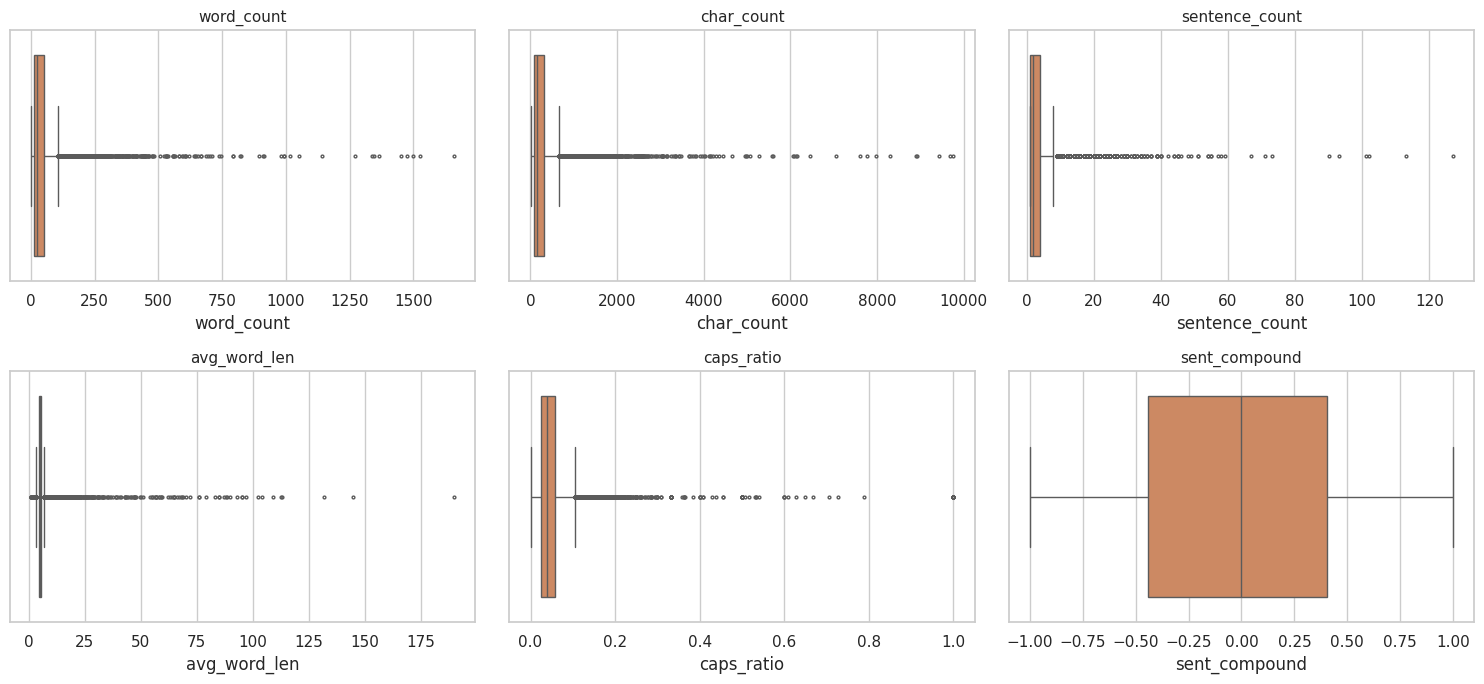

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), ["word_count", "char_count", "sentence_count",
                                "avg_word_len", "caps_ratio", "sent_compound"]):
    sns.boxplot(x=data[c], ax=ax, color="#dd8452", fliersize=2)
    ax.set_title(c, fontsize=11)
plt.tight_layout()
save("boxplots")

In [21]:
rows = []
for c in NUM_COLS:
    q1, q3 = data[c].quantile([.25, .75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    k = int(((data[c] < lo) | (data[c] > hi)).sum())
    rows.append({"ознака": c, "нижня межа": round(lo, 2), "верхня межа": round(hi, 2),
                 "викидів": k, "%": round(k / len(data) * 100, 2)})
pd.DataFrame(rows).sort_values("викидів", ascending=False).reset_index(drop=True)

,ознака,нижня межа,верхня межа,викидів,%
0,question,0.00,0.00,4015,22.90
1,quote_lines,0.00,0.00,2800,15.97
2,digits,-3.00,5.00,2729,15.56
3,link_count,0.00,0.00,2491,14.21
4,avg_word_len,3.08,6.71,1948,11.11
5,n_paragraphs,-0.50,3.50,1677,9.56
6,word_count,-45.00,107.00,1371,7.82
7,char_count,-273.50,658.50,1346,7.68
8,caps_ratio,-0.02,0.11,1148,6.55
9,sentence_count,-3.50,8.50,1007,5.74


Викиди тут не помилки вимірювання, а реальні довгі коментарі з цитатами й посиланнями.
Видаляти їх не можна: саме такі коментарі несуть найбільше змісту в обговоренні новин.
Замість видалення застосовую логарифмування з розділу 4.2.

### 6.4 Категоріальні змінні

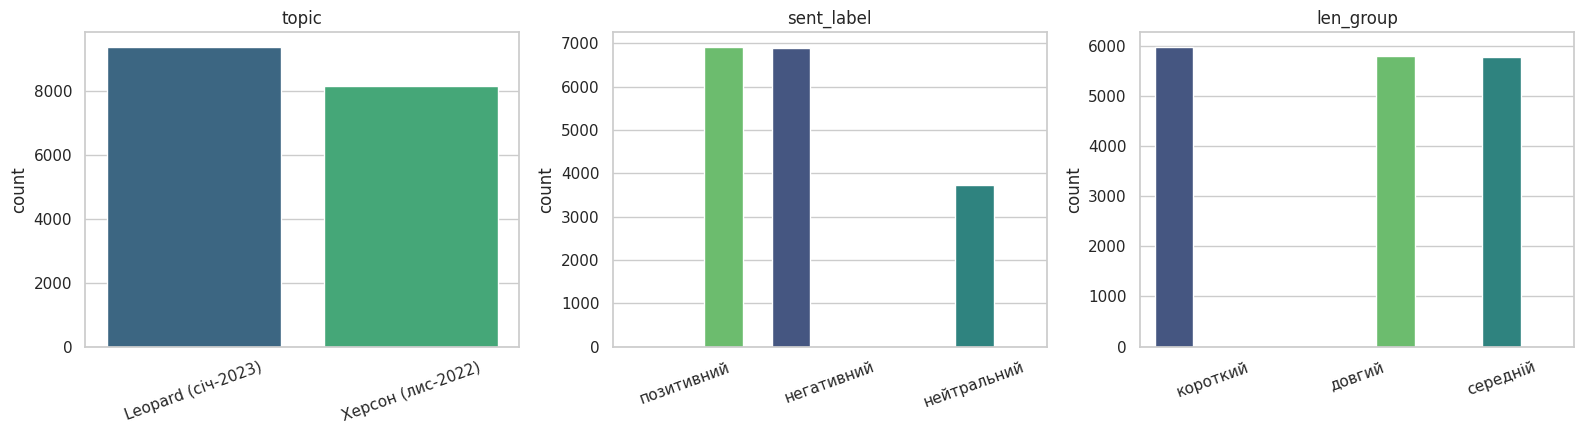

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, c in zip(axes, CAT_COLS):
    order = data[c].value_counts().index
    sns.countplot(data=data, x=c, order=order, ax=ax, hue=c,
                  palette="viridis", legend=False)
    ax.set_title(c)
    ax.tick_params(axis="x", rotation=20)
    ax.set_xlabel("")
plt.tight_layout()
save("categorical_counts")

### 6.5 Зв'язки між змінними

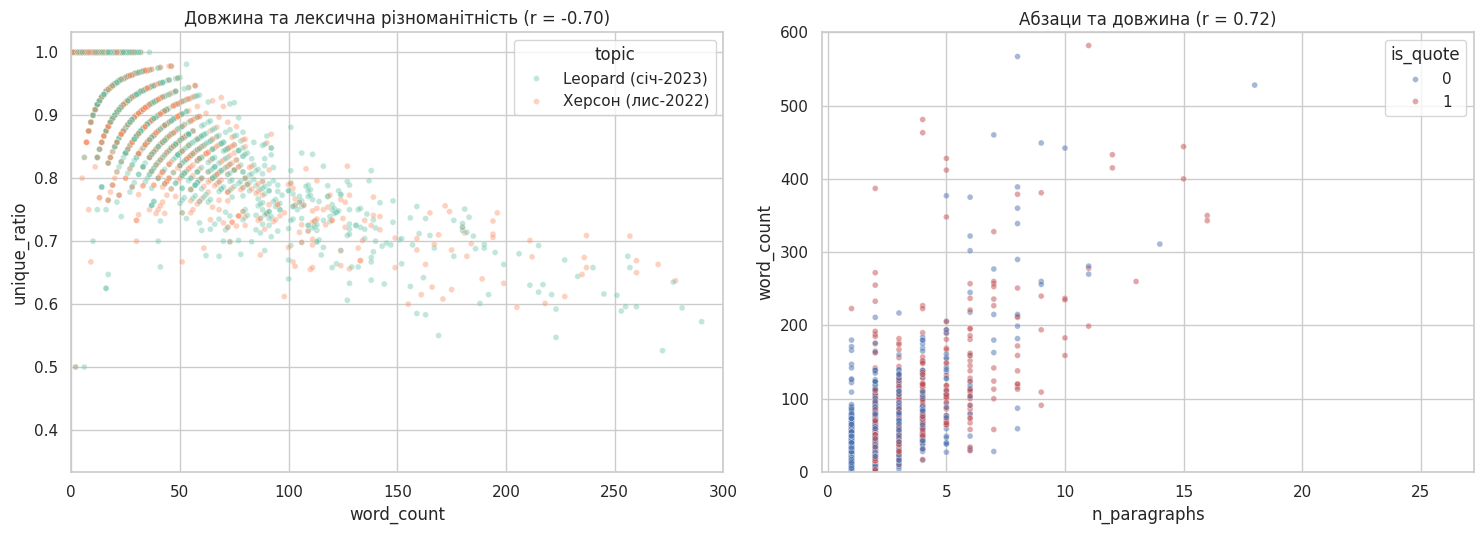

In [23]:
sample = data.sample(3000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.scatterplot(data=sample, x="word_count", y="unique_ratio", hue="topic",
                alpha=.4, s=18, ax=axes[0], palette="Set2")
axes[0].set_xlim(0, 300)
axes[0].set_title(f"Довжина та лексична різноманітність (r = "
                  f"{data['word_count'].corr(data['unique_ratio']):.2f})")

sns.scatterplot(data=sample, x="n_paragraphs", y="word_count", hue="is_quote",
                alpha=.5, s=18, ax=axes[1], palette=["#4c72b0", "#c44e52"])
axes[1].set_ylim(0, 600)
axes[1].set_title(f"Абзаци та довжина (r = "
                  f"{data['n_paragraphs'].corr(data['word_count']):.2f})")
plt.tight_layout()
save("scatter_relations")

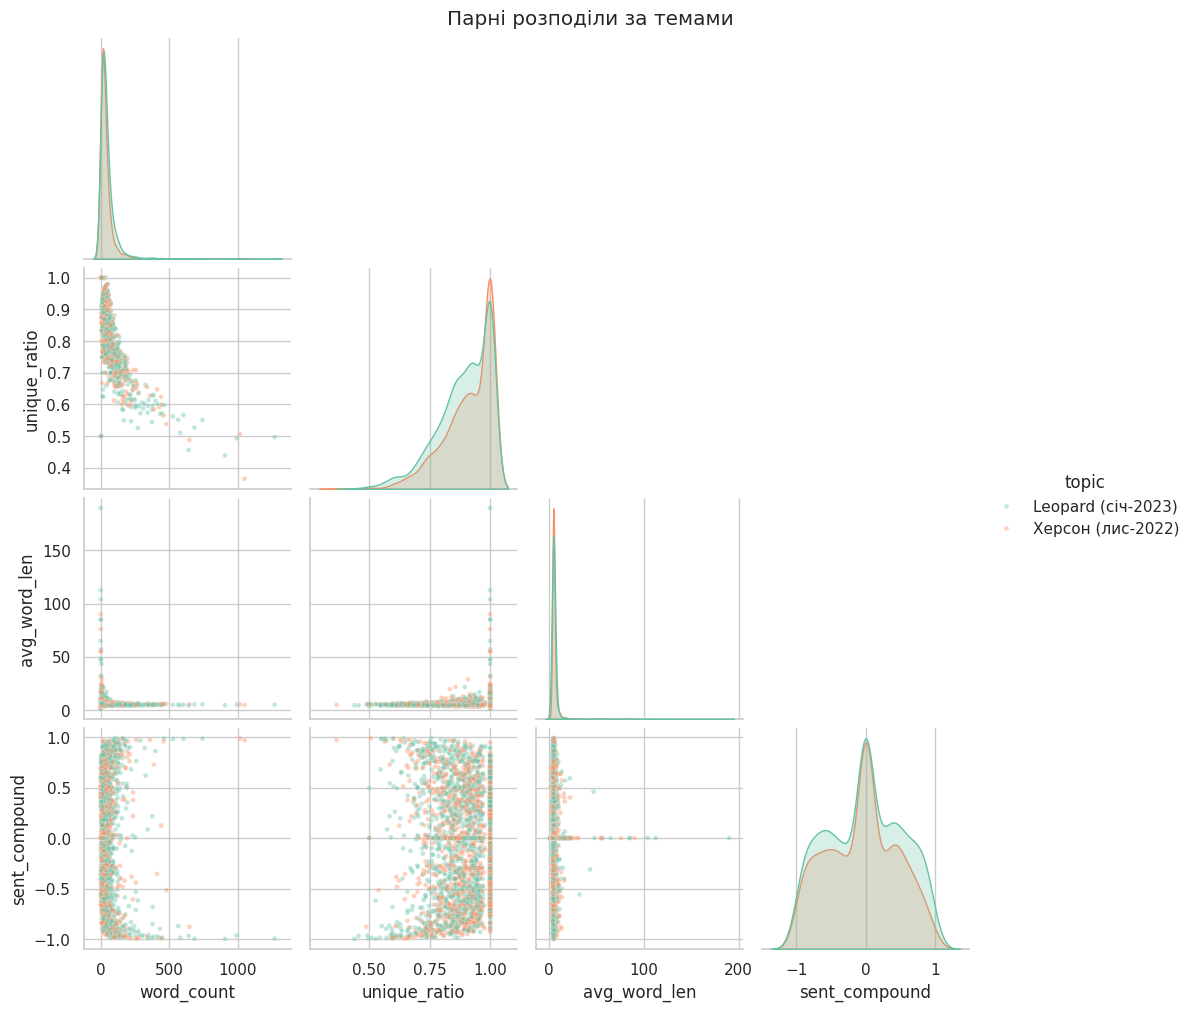

In [24]:
g = sns.pairplot(sample[["word_count", "unique_ratio", "avg_word_len",
                         "sent_compound", "topic"]],
                 hue="topic", diag_kind="kde", corner=True, palette="Set2",
                 plot_kws={"alpha": .4, "s": 12})
g.figure.suptitle("Парні розподіли за темами", y=1.01)
save("pairplot")

### 6.6 Порівняння двох обговорень

,word_count,char_count,link_count,quote_lines,caps_ratio,sent_compound,unique_ratio
topic,,,,,,,
Leopard (січ-2023),48.673,295.729,0.160,0.336,0.050,-0.003,0.890
Херсон (лис-2022),37.676,233.924,0.172,0.298,0.051,-0.040,0.909


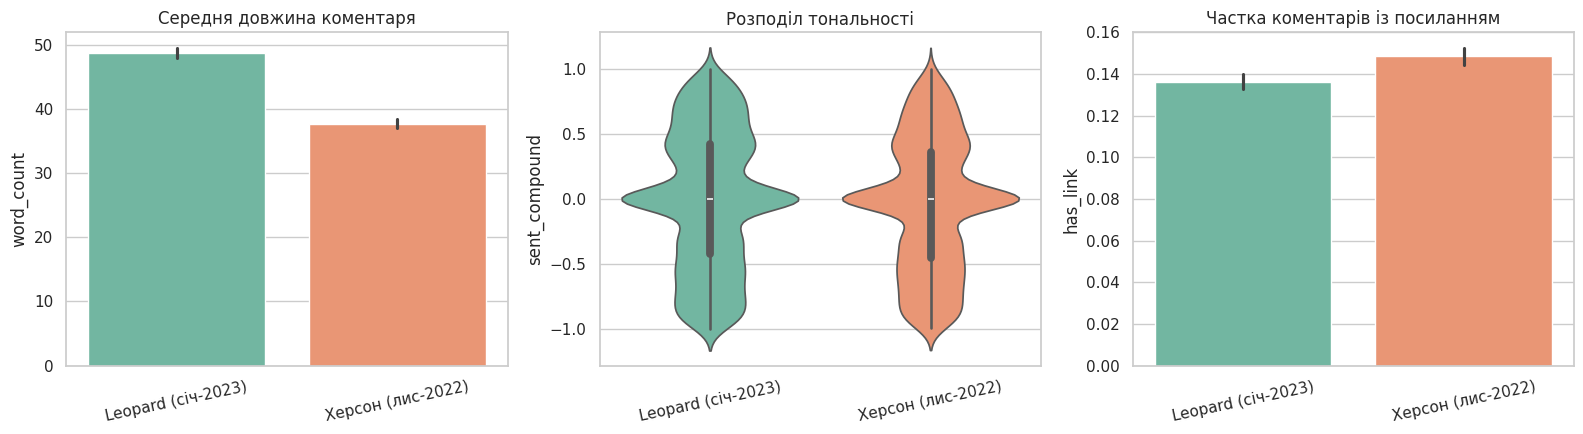

In [25]:
cmp = data.groupby("topic", observed=True)[
    ["word_count", "char_count", "link_count", "quote_lines",
     "caps_ratio", "sent_compound", "unique_ratio"]].mean().round(3)
display(cmp)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.barplot(data=data, x="topic", y="word_count", ax=axes[0], hue="topic",
            palette="Set2", legend=False, errorbar="se")
axes[0].set_title("Середня довжина коментаря")
sns.violinplot(data=data, x="topic", y="sent_compound", ax=axes[1], hue="topic",
               palette="Set2", legend=False)
axes[1].set_title("Розподіл тональності")
sns.barplot(data=data, x="topic", y="has_link", ax=axes[2], hue="topic",
            palette="Set2", legend=False, errorbar="se")
axes[2].set_title("Частка коментарів із посиланням")
for ax in axes:
    ax.tick_params(axis="x", rotation=12)
    ax.set_xlabel("")
plt.tight_layout()
save("topic_comparison")

In [26]:
# Чи відрізняється тональність між темами статистично
from scipy import stats as st
a = data.loc[data["topic"] == "Leopard (січ-2023)", "sent_compound"]
b = data.loc[data["topic"] == "Херсон (лис-2022)", "sent_compound"]
tstat, pval = st.ttest_ind(a, b, equal_var=False)
print(f"t-критерій для sent_compound: t = {tstat:.3f}, p = {pval:.4f}")
print("Різниця середніх:", round(a.mean() - b.mean(), 4))
print("Висновок:", "різниця значуща (p < 0.05)" if pval < 0.05 else "різниця незначуща")

t-критерій для sent_compound: t = 4.763, p = 0.0000
Різниця середніх: 0.0372
Висновок: різниця значуща (p < 0.05)


## 7. Побудова моделей

### 7.1 Лінійна регресія: прогноз довжини коментаря

Ціль — `word_count`. З предикторів прибираю `char_count` і `sentence_count`: вони вимірюють
той самий обсяг тексту іншими одиницями, тому модель із ними була б тавтологією
з R² близьким до одиниці.

In [27]:
REG_FEATURES = ["avg_word_len", "unique_ratio", "n_paragraphs", "link_count", "quote_lines",
                "exclam", "question", "digits", "mentions", "caps_ratio",
                "sent_compound", "sent_pos", "sent_neg", "has_link", "is_quote"]

X = pd.get_dummies(data[REG_FEATURES + ["topic"]], columns=["topic"], drop_first=True).astype(float)
y = data["word_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train)          # навчаємо тільки на train, щоб уникнути витоку
X_train_s, X_test_s = scaler.transform(X_train), scaler.transform(X_test)

lin = LinearRegression().fit(X_train_s, y_train)
pred = lin.predict(X_test_s)

print("=== Лінійна регресія ===")
print(f"R² навчальна: {lin.score(X_train_s, y_train):.3f}")
print(f"R² тестова:   {r2_score(y_test, pred):.3f}")
print(f"MAE:  {mean_absolute_error(y_test, pred):.2f} слів")
print(f"RMSE: {root_mean_squared_error(y_test, pred):.2f} слів")
print(f"\nДля порівняння: середня довжина {y_test.mean():.1f}, "
      f"медіана {y_test.median():.0f}, стандартне відхилення {y_test.std():.1f}")

=== Лінійна регресія ===
R² навчальна: 0.722
R² тестова:   0.723
MAE:  17.36 слів
RMSE: 37.32 слів

Для порівняння: середня довжина 44.5, медіана 25, стандартне відхилення 70.9


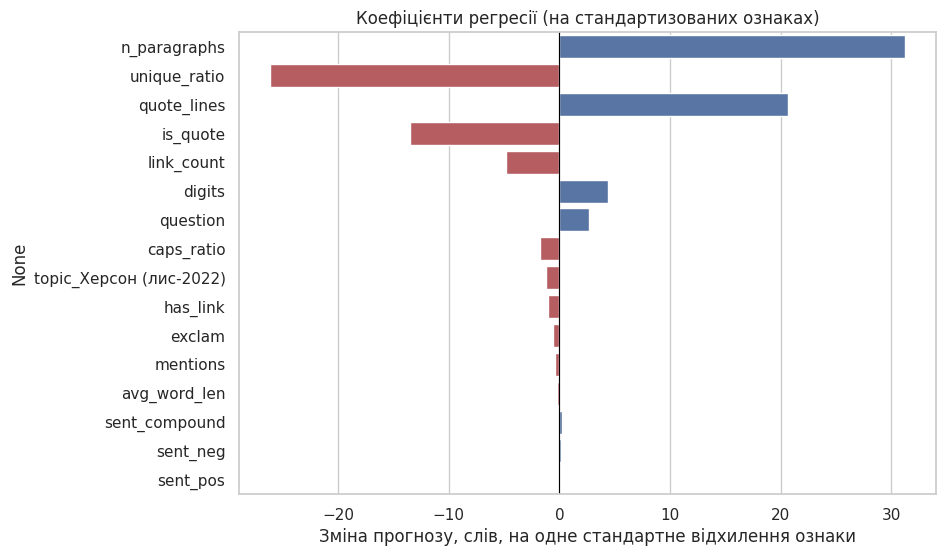

n_paragraphs               31.18
unique_ratio              -26.09
quote_lines                20.64
is_quote                  -13.45
link_count                 -4.82
digits                      4.42
question                    2.70
caps_ratio                 -1.72
topic_Херсон (лис-2022)    -1.16
has_link                   -0.98
exclam                     -0.53
mentions                   -0.35
avg_word_len               -0.22
sent_compound               0.20
sent_neg                    0.16
sent_pos                    0.00
dtype: float64

In [28]:
coef = pd.Series(lin.coef_, index=X.columns).sort_values(key=abs, ascending=False)
plt.figure(figsize=(9, 6))
colors = ["#c44e52" if v < 0 else "#4c72b0" for v in coef.values]
sns.barplot(x=coef.values, y=coef.index, palette=colors, hue=coef.index, legend=False)
plt.axvline(0, color="black", lw=.8)
plt.title("Коефіцієнти регресії (на стандартизованих ознаках)")
plt.xlabel("Зміна прогнозу, слів, на одне стандартне відхилення ознаки")
save("regression_coefficients")
coef.round(2)

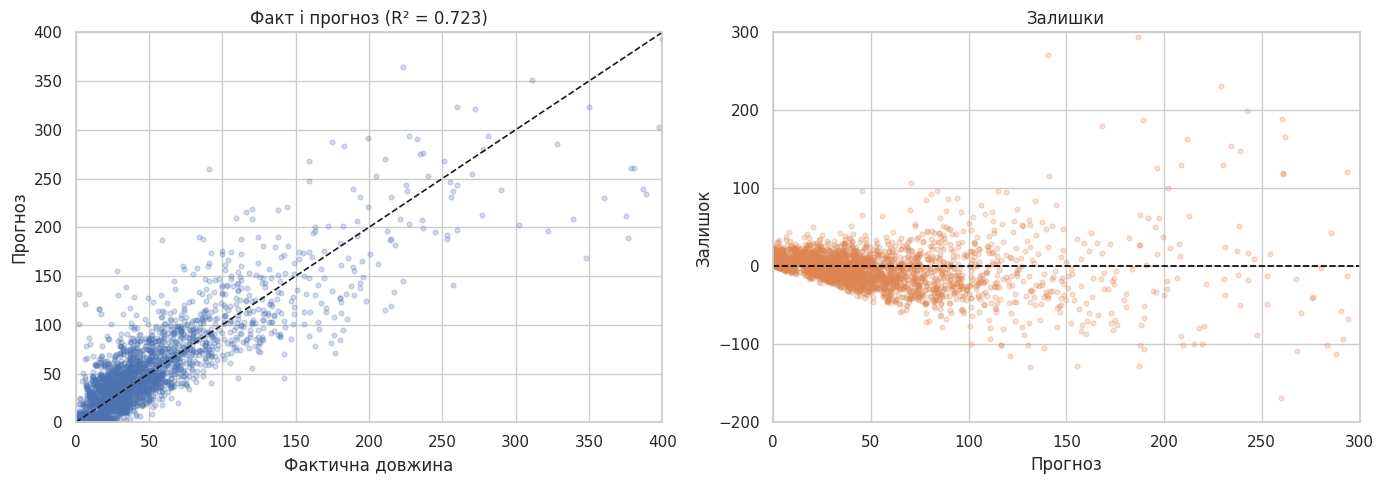

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, pred, alpha=.25, s=12, color="#4c72b0")
lims = [0, 400]
axes[0].plot(lims, lims, "k--", lw=1.2)
axes[0].set(xlim=lims, ylim=lims, xlabel="Фактична довжина",
            ylabel="Прогноз", title=f"Факт і прогноз (R² = {r2_score(y_test, pred):.3f})")

resid = y_test - pred
axes[1].scatter(pred, resid, alpha=.25, s=12, color="#dd8452")
axes[1].axhline(0, color="black", ls="--", lw=1.2)
axes[1].set(xlim=(0, 300), ylim=(-200, 300), xlabel="Прогноз",
            ylabel="Залишок", title="Залишки")
plt.tight_layout()
save("regression_diagnostics")

Залишки розходяться віялом: чим довший коментар, тим більша помилка. Це гетероскедастичність,
типова для величин із правостороннім хвостом. Перевіряю два способи впоратись: логарифм цілі
та нелінійну модель.

In [30]:
# Варіант з логарифмом цілі
y_log = np.log1p(y)
Xtr2, Xte2, ytr2, yte2 = train_test_split(X, y_log, test_size=0.2, random_state=RANDOM_STATE)
sc2 = StandardScaler().fit(Xtr2)
lin_log = LinearRegression().fit(sc2.transform(Xtr2), ytr2)
r2_log = r2_score(yte2, lin_log.predict(sc2.transform(Xte2)))

# Нелінійна модель
rf = RandomForestRegressor(n_estimators=120, max_depth=14,
                           random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train)
r2_rf = r2_score(y_test, rf.predict(X_test))

results = pd.DataFrame({
    "модель": ["Лінійна регресія", "Лінійна регресія на log(y)", "Випадковий ліс"],
    "R² тест": [round(r2_score(y_test, pred), 3), round(r2_log, 3), round(r2_rf, 3)],
})
display(results)

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nВажливість ознак у випадковому лісі:")
print(imp.head(8).round(3).to_string())

,модель,R² тест
0,Лінійна регресія,0.723
1,Лінійна регресія на log(y),0.736
2,Випадковий ліс,0.867



Важливість ознак у випадковому лісі:
unique_ratio     0.743
n_paragraphs     0.098
digits           0.030
sent_neg         0.027
sent_pos         0.023
sent_compound    0.020
avg_word_len     0.018
caps_ratio       0.013


### 7.2 Класифікація: до якого обговорення належить коментар

Порівнюю два підходи. Перший використовує лише сконструйовані числові ознаки, другий —
сам текст через TF-IDF. Різниця між ними показує, що саме несе інформацію про тему.

In [31]:
y_cls = (data["post_id"] == "10eps9y").astype(int)   # 1 = Leopard, 0 = Херсон
baseline = max(y_cls.mean(), 1 - y_cls.mean())
print(f"Базовий рівень (завжди більший клас): {baseline:.3f}")

# --- Модель А: числові ознаки ---
X_a = pd.get_dummies(data[REG_FEATURES + ["sent_label", "len_group"]],
                     columns=["sent_label", "len_group"], drop_first=True).astype(float)
Xa_tr, Xa_te, ya_tr, ya_te = train_test_split(X_a, y_cls, test_size=0.2,
                                              random_state=RANDOM_STATE, stratify=y_cls)
mm = MinMaxScaler().fit(Xa_tr)
clf_a = LogisticRegression(max_iter=1000).fit(mm.transform(Xa_tr), ya_tr)
proba_a = clf_a.predict_proba(mm.transform(Xa_te))[:, 1]

acc_a = accuracy_score(ya_te, clf_a.predict(mm.transform(Xa_te)))
auc_a = roc_auc_score(ya_te, proba_a)
print(f"\nМодель А (числові ознаки): accuracy {acc_a:.3f}, ROC-AUC {auc_a:.3f}")

Базовий рівень (завжди більший клас): 0.535

Модель А (числові ознаки): accuracy 0.551, ROC-AUC 0.577


In [32]:
# --- Модель Б: TF-IDF по тексту ---
txt_tr, txt_te, yb_tr, yb_te = train_test_split(
    data["comment_body"], y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls)

vec = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), min_df=3,
                      sublinear_tf=True, stop_words="english")
V_tr = vec.fit_transform(txt_tr)     # словник будуємо лише на навчальній вибірці
V_te = vec.transform(txt_te)

clf_b = LogisticRegression(max_iter=2000, C=3).fit(V_tr, yb_tr)
pred_b = clf_b.predict(V_te)
proba_b = clf_b.predict_proba(V_te)[:, 1]

acc_b = accuracy_score(yb_te, pred_b)
auc_b = roc_auc_score(yb_te, proba_b)
print(f"Розмір словника: {len(vec.vocabulary_)} ознак")
print(f"Модель Б (TF-IDF): accuracy {acc_b:.3f}, ROC-AUC {auc_b:.3f}\n")
print(classification_report(yb_te, pred_b,
      target_names=["Херсон (лис-2022)", "Leopard (січ-2023)"], digits=3))

Розмір словника: 20000 ознак
Модель Б (TF-IDF): accuracy 0.731, ROC-AUC 0.820

                    precision    recall  f1-score   support

 Херсон (лис-2022)      0.713     0.706     0.709      1631
Leopard (січ-2023)      0.746     0.753     0.750      1876

          accuracy                          0.731      3507
         macro avg      0.730     0.729     0.730      3507
      weighted avg      0.731     0.731     0.731      3507



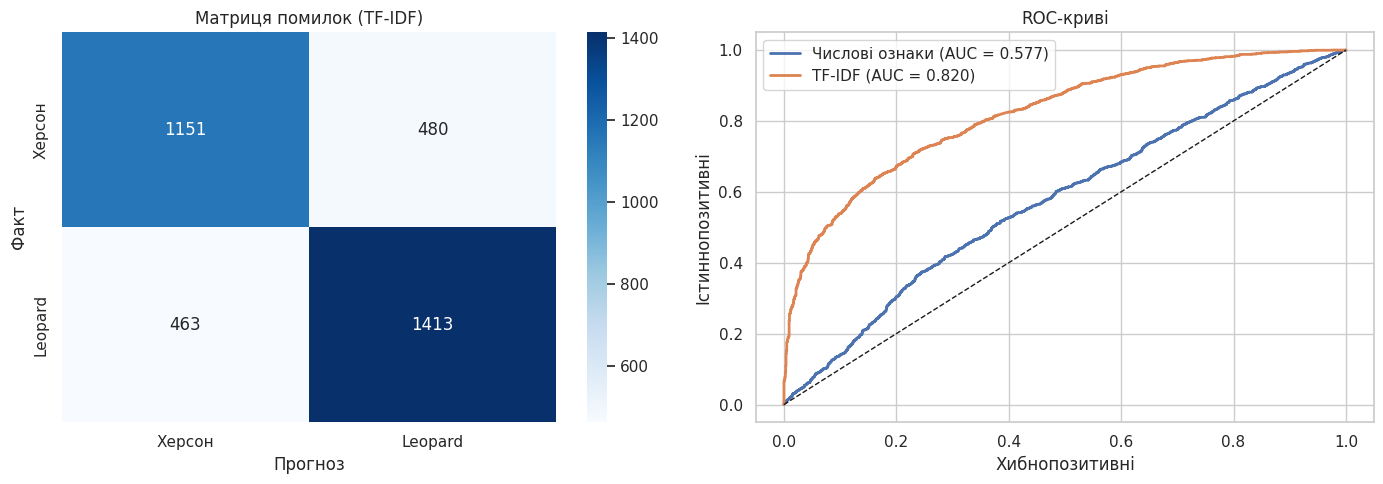

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(yb_te, pred_b)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Херсон", "Leopard"], yticklabels=["Херсон", "Leopard"])
axes[0].set(xlabel="Прогноз", ylabel="Факт", title="Матриця помилок (TF-IDF)")

for name, yt, pr, auc in [("Числові ознаки", ya_te, proba_a, auc_a),
                          ("TF-IDF", yb_te, proba_b, auc_b)]:
    fpr, tpr, _ = roc_curve(yt, pr)
    axes[1].plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set(xlabel="Хибнопозитивні", ylabel="Істиннопозитивні", title="ROC-криві")
axes[1].legend()
plt.tight_layout()
save("classification_results")

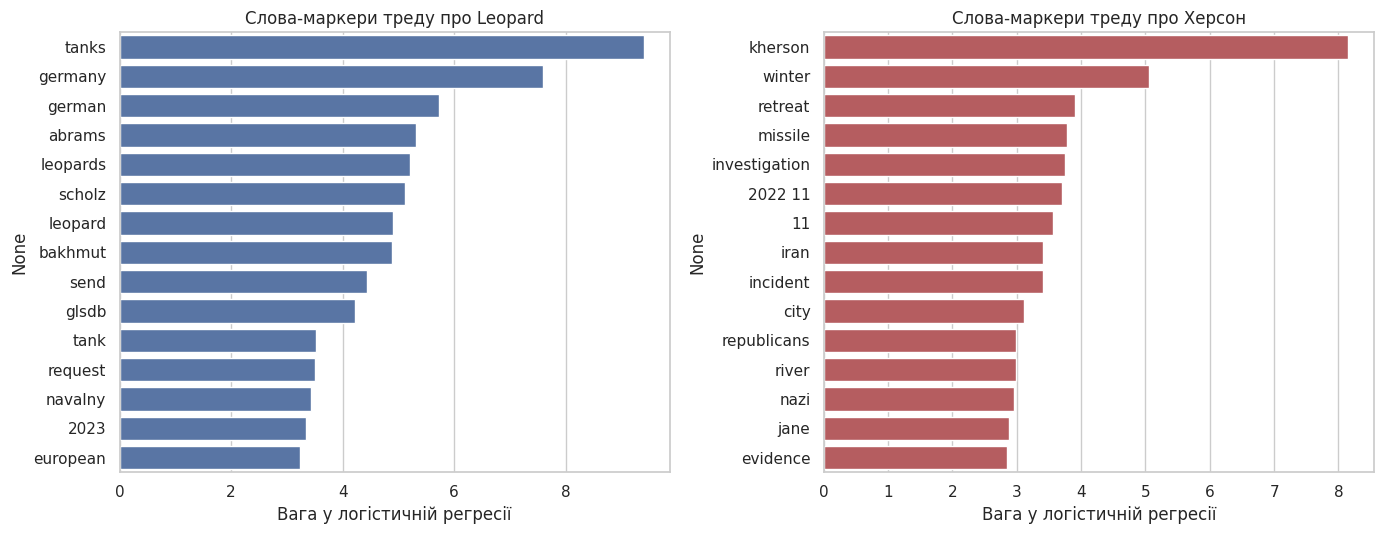

In [34]:
weights = pd.Series(clf_b.coef_[0], index=vec.get_feature_names_out())
top_leo, top_kher = weights.nlargest(15), weights.nsmallest(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
sns.barplot(x=top_leo.values, y=top_leo.index, ax=axes[0], color="#4c72b0")
axes[0].set_title("Слова-маркери треду про Leopard")
sns.barplot(x=top_kher.abs().values, y=top_kher.index, ax=axes[1], color="#c44e52")
axes[1].set_title("Слова-маркери треду про Херсон")
for ax in axes:
    ax.set_xlabel("Вага у логістичній регресії")
plt.tight_layout()
save("top_words")

In [35]:
# Перехресна перевірка: чи стабільна якість на різних розбиттях
cv = cross_val_score(LogisticRegression(max_iter=2000, C=3),
                     vec.transform(data["comment_body"]), y_cls, cv=5, scoring="accuracy")
print("Accuracy на 5 фолдах:", np.round(cv, 3))
print(f"Середнє: {cv.mean():.3f} ± {cv.std():.3f}")

Accuracy на 5 фолдах: [0.713 0.716 0.704 0.727 0.707]
Середнє: 0.713 ± 0.008


### 7.3 Підсумок моделей

In [36]:
summary = pd.DataFrame([
    {"задача": "Регресія", "модель": "Лінійна регресія", "ціль": "word_count",
     "метрика": "R²", "значення": round(r2_score(y_test, pred), 3)},
    {"задача": "Регресія", "модель": "Випадковий ліс", "ціль": "word_count",
     "метрика": "R²", "значення": round(r2_rf, 3)},
    {"задача": "Класифікація", "модель": "Лог. регресія на числових ознаках", "ціль": "post_id",
     "метрика": "accuracy", "значення": round(acc_a, 3)},
    {"задача": "Класифікація", "модель": "Лог. регресія на TF-IDF", "ціль": "post_id",
     "метрика": "accuracy", "значення": round(acc_b, 3)},
])
display(summary)

summary.to_csv("output/model_results.csv", index=False)
data.to_csv("output/cleaned_featured_dataset.csv", index=False)
data[NUM_COLS].describe().T.round(3).to_csv("output/descriptive_stats.csv")
corr.round(3).to_csv("output/correlation_matrix.csv")
print("\nЗбережено:", sorted(os.listdir("output")))
print("Графіки:", sorted(os.listdir("figures")))

,задача,модель,ціль,метрика,значення
0,Регресія,Лінійна регресія,word_count,R²,0.723
1,Регресія,Випадковий ліс,word_count,R²,0.867
2,Класифікація,Лог. регресія на числових ознаках,post_id,accuracy,0.551
3,Класифікація,Лог. регресія на TF-IDF,post_id,accuracy,0.731



Збережено: ['cleaned_featured_dataset.csv', 'correlation_matrix.csv', 'descriptive_stats.csv', 'model_results.csv']
Графіки: ['boxplots.png', 'categorical_counts.png', 'classification_results.png', 'correlation_matrix.png', 'histograms.png', 'log_transform.png', 'pairplot.png', 'regression_coefficients.png', 'regression_diagnostics.png', 'scatter_relations.png', 'top_words.png', 'topic_comparison.png']


## 8. Висновки

### Про набір даних

Файл містить 18 183 коментарі з двох мегатредів r/europe: січневого 2023 року про постачання
танків Leopard 2 і листопадового 2022 року про звільнення Херсона. Усі три колонки текстові,
жодної кількісної змінної немає, тому весь подальший аналіз спирається на 16 ознак,
які я витягнув із тексту.

### Очищення

Reddit позначає видалені коментарі як `[deleted]` та `[removed]`; таких виявилось 648, або 3.56%.
Я їх прибрав, бо тексту в них немає, а всі ознаки з них були б артефактами обробки.
Дублікатів і пропущених значень у файлі не виявилось. Після очищення залишилось 17 535 записів.

### Описова статистика

Медіанний коментар містить 25 слів і 148 символів, тоді як середнє становить 44.5 слова.
Розрив між середнім і медіаною майже вдвічі означає сильну правосторонню асиметрію: більшість
коментарів короткі, а окремі сягають 9 763 символів. Асиметрія `word_count` дорівнює 8.3,
тому для моделювання я логарифмував цю змінну.

Посилання містять 14.2% коментарів, цитати іншого допису — 16.0%. Тональність розподілилась
майже порівну: 39.4% позитивних і 39.3% негативних коментарів за шкалою VADER.

### Викиди

За правилом 1.5×IQR найбільше викидів у `question` (22.9%) та `quote_lines` (16.0%).
Це не помилки даних, а довгі коментарі з цитатами й посиланнями на джерела. Видалення таких
записів знищило б найзмістовнішу частину обговорення, тому я застосував логарифмування.

### Кореляції

Найсильніші зв'язки очікувані та механічні: `char_count` і `word_count` дають r = 0.99,
бо вимірюють той самий обсяг тексту. Змістовні результати інші.

Частка унікальних слів падає зі зростанням довжини (r = −0.70): у довгих коментарях автори
повторюють службові слова, лексична різноманітність знижується.

Кількість посилань корелює з кількістю цифр (r = 0.68) — цифри приходять усередині самих URL
разом із датами та ідентифікаторами твітів.

Тональність не корелює з жодною структурною ознакою сильніше за |r| = 0.2. Довжина коментаря
нічого не говорить про його емоційне забарвлення.

t-критерій показує значущу різницю тональності між тредами (p < 0.001), але сама різниця
середніх становить 0.037 за шкалою від −1 до +1. На вибірці у 17.5 тисяч записів значущим
стає майже будь-який ефект, тому тут важливіший його розмір: практично тональність однакова.

### Моделювання

**Регресія.** Лінійна модель пояснює 72.3% дисперсії довжини коментаря (R² = 0.723 на тестовій
вибірці, MAE 17.4 слова). Розрив між навчальною та тестовою вибіркою відсутній, отже
перенавчання немає. Головні предиктори — кількість абзаців (+31.2 слова на стандартне
відхилення) та частка унікальних слів (−26.1). Випадковий ліс піднімає R² до 0.867, що вказує
на нелінійність зв'язку; у ньому 74% важливості припадає на `unique_ratio`.

Діагностика залишків показує гетероскедастичність: помилка зростає разом із довжиною
коментаря. Логарифмування цілі дає R² = 0.736 і вирівнює залишки.

**Класифікація.** Модель на числових ознаках дала accuracy 0.551 проти базового рівня 0.535,
тобто майже нічого. Це змістовний результат: за довжиною, форматуванням і тональністю
неможливо визначити, у якому обговоренні написано коментар. Обидві дискусії мають однакову
структуру мовлення.

Та сама логістична регресія на TF-IDF досягає accuracy 0.731 і ROC-AUC 0.820. Інформацію про
тему несе лексика, а не форма. Ваги моделі це підтверджують: тред про Leopard упізнається за
словами tanks, germany, abrams, scholz, leopards; тред про Херсон — за kherson, winter, retreat,
missile, iran.

### Обмеження

VADER навчений на англомовних текстах соцмереж і не розпізнає сарказм, якого в політичних
дискусіях багато. Оцінки тональності варто читати як приблизні.

Двох обговорень замало, щоб узагальнювати висновки на весь r/europe. Дані охоплюють два
конкретні інформаційні приводи з різницею у два місяці.

Кореляція не доводить причинності. Зв'язок довжини з кількістю абзаців відображає спільну
природу обох величин, а не вплив одної на іншу.